=============================================================================
DRUG TOXICITY PREDICTION — COMPLETE COLAB NOTEBOOK
CodeCure AI Hackathon · Track A
Architecture: XGBoost Baseline → Multi-task GNN → Ensemble + SHAP
=============================================================================

─────────────────────────────────────────────────────────────────────────────


## Run Order (Required)
1. Run Cell 1 to install dependencies.
2. Restart kernel.
3. Run Cell 2 dependency verification.
4. Run Cell 3 imports.
5. Continue with remaining cells.

If Cell 2 fails, do not continue. Re-run Cell 1 and restart kernel.

In [4]:
# CELL 1 · Install all dependencies
# Run this first, then restart the kernel.

import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules

BASE_PACKAGES = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "xgboost",
    "shap",
    "umap-learn",
    "torch",
    "tqdm",
    "imbalanced-learn",
    "streamlit",
    "py3Dmol",
    "joblib",
]


def pip_install(args):
    cmd = [sys.executable, "-m", "pip", "install", "--prefer-binary", *args]
    print("RUN:", " ".join(cmd))
    return subprocess.run(cmd, check=False)


print(f"Python executable: {sys.executable}")
print("Upgrading pip/setuptools/wheel...")
upgrade_proc = subprocess.run(
    [sys.executable, "-m", "pip", "install", "--upgrade", "pip", "setuptools", "wheel"],
    check=False,
)
if upgrade_proc.returncode != 0:
    raise RuntimeError("Failed to upgrade pip tooling. Resolve this before continuing.")

print("Installing RDKit...")
rdkit_candidates = ["rdkit-pypi", "rdkit"]
rdkit_ok = False
for candidate in rdkit_candidates:
    proc = pip_install([candidate])
    if proc.returncode == 0:
        rdkit_ok = True
        print(f"RDKit installed using package: {candidate}")
        break
    print(f"Failed RDKit candidate: {candidate}")

if not rdkit_ok:
    raise RuntimeError(
        "Could not install RDKit using any supported package name (rdkit-pypi, rdkit)."
    )

print("Installing remaining base packages one by one...")
failed_packages = []
for pkg in BASE_PACKAGES:
    proc = pip_install([pkg])
    if proc.returncode != 0:
        failed_packages.append(pkg)

if failed_packages:
    raise RuntimeError(
        "Failed to install required packages: " + ", ".join(failed_packages)
    )

print("Installing torch-geometric...")
pyg_proc = pip_install(["torch-geometric"])
if pyg_proc.returncode != 0:
    print("Primary torch-geometric install failed.")
    if IN_COLAB:
        print("Trying Colab-compatible fallback wheel install...")
        fallback_proc = subprocess.run(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "pyg_lib",
                "torch_scatter",
                "torch_sparse",
                "torch_cluster",
                "torch_spline_conv",
                "-f",
                "https://data.pyg.org/whl/torch-2.0.0+cu118.html",
            ],
            check=False,
        )
        if fallback_proc.returncode != 0:
            raise RuntimeError(
                "torch-geometric fallback dependency wheels failed in Colab environment."
            )
        final_pyg = pip_install(["torch-geometric"])
        if final_pyg.returncode != 0:
            raise RuntimeError("torch-geometric final installation failed after fallback.")
    else:
        raise RuntimeError(
            "torch-geometric installation failed on this environment. "
            "Check your PyTorch/CUDA compatibility before continuing."
        )

print("Dependency installation finished.")
print("IMPORTANT: Restart kernel now, then run Cell 2.")

Python executable: /usr/bin/python3
Upgrading pip/setuptools/wheel...
Installing RDKit...
RUN: /usr/bin/python3 -m pip install --prefer-binary rdkit-pypi
Failed RDKit candidate: rdkit-pypi
RUN: /usr/bin/python3 -m pip install --prefer-binary rdkit
RDKit installed using package: rdkit
Installing remaining base packages one by one...
RUN: /usr/bin/python3 -m pip install --prefer-binary numpy
RUN: /usr/bin/python3 -m pip install --prefer-binary pandas
RUN: /usr/bin/python3 -m pip install --prefer-binary matplotlib
RUN: /usr/bin/python3 -m pip install --prefer-binary seaborn
RUN: /usr/bin/python3 -m pip install --prefer-binary scikit-learn
RUN: /usr/bin/python3 -m pip install --prefer-binary xgboost
RUN: /usr/bin/python3 -m pip install --prefer-binary shap
RUN: /usr/bin/python3 -m pip install --prefer-binary umap-learn
RUN: /usr/bin/python3 -m pip install --prefer-binary torch
RUN: /usr/bin/python3 -m pip install --prefer-binary tqdm
RUN: /usr/bin/python3 -m pip install --prefer-binary imb

In [1]:
# CELL 2 · Dependency Verification (always run after restart)

import importlib
import sys

REQUIRED_MODULES = {
    "rdkit": "rdkit",
    "torch": "torch",
    "torch_geometric": "torch_geometric",
    "xgboost": "xgboost",
    "shap": "shap",
    "umap": "umap",
}

print(f"Python executable: {sys.executable}")
missing = []

for display_name, module_name in REQUIRED_MODULES.items():
    try:
        importlib.import_module(module_name)
        print(f"OK: {display_name}")
    except Exception as exc:
        print(f"MISSING: {display_name} -> {exc}")
        missing.append(display_name)

if missing:
    raise ModuleNotFoundError(
        "Missing required packages: " + ", ".join(missing) + ". "
        "Re-run Cell 1 and restart the kernel before continuing."
    )

print("All required dependencies are available.")

Python executable: /usr/bin/python3
OK: rdkit
OK: torch
OK: torch_geometric
OK: xgboost
OK: shap
OK: umap
All required dependencies are available.


In [ ]:
# CELL 2b - Google Drive Mount + Persistent Directory Setup
# -------------------------------------------------------------------------
# Run this every session BEFORE any cell that reads/writes data or models.
# In Colab:  mounts Drive and symlinks ./models + ./data to Drive so all
#            model files survive disconnects and runtime resets.
# Locally:   creates ./models and ./data if they don't exist.
# -------------------------------------------------------------------------

import os, sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    DRIVE_BASE = '/content/drive/MyDrive/drug_toxicity'
    os.makedirs(f'{DRIVE_BASE}/models',           exist_ok=True)
    os.makedirs(f'{DRIVE_BASE}/data/tox21',       exist_ok=True)
    os.makedirs(f'{DRIVE_BASE}/data/explanations', exist_ok=True)

    # Symlink /content/models -> Drive so every ./models path in code
    # transparently writes to Drive without changing any existing cell.
    for local, remote in [
        ('/content/models', f'{DRIVE_BASE}/models'),
        ('/content/data',   f'{DRIVE_BASE}/data'),
    ]:
        if not os.path.exists(local):
            os.symlink(remote, local)
        elif not os.path.islink(local):
            # Already a real dir from a previous run - just leave it
            pass

    os.chdir('/content')
    print('Google Drive mounted.')
    print(f'  Models persist at : {DRIVE_BASE}/models/')
    print(f'  Data persists at  : {DRIVE_BASE}/data/')

else:
    os.makedirs('./models',           exist_ok=True)
    os.makedirs('./data/tox21',       exist_ok=True)
    os.makedirs('./data/explanations', exist_ok=True)
    print('Running locally.')
    print('  Models -> ./models/')
    print('  Data   -> ./data/')

print('Directory setup complete.')


In [2]:
# CELL 3 · Imports

import os
import warnings
import random

warnings.filterwarnings("ignore")
random.seed(42)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from tqdm import tqdm

# RDKit
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors, Draw, rdMolDescriptors
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit import RDLogger

RDLogger.DisableLog("rdApp.*")

# ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import xgboost as xgb
import shap

# Torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# PyTorch Geometric
from torch_geometric.data import Data, DataLoader as PyGDataLoader
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, global_max_pool

# UMAP
import umap

print("Imports successful")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Imports successful
PyTorch: 2.10.0+cpu
CUDA available: False
Device: cpu


In [3]:
# CELL 3 · Download Tox21 Dataset from Kaggle
# ─────────────────────────────────────────────────────────────────────────────
# Option A: Kaggle API (recommended)
# Upload your kaggle.json first, or set credentials below

# from google.colab import files
# files.upload()  # upload kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d epicskills/tox21-dataset --unzip -p ./data/tox21

# Option B: Download directly from DeepChem (always works, no API key needed)
import urllib.request

os.makedirs("./data/tox21", exist_ok=True)

TOX21_TRAIN_URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz"
TOX21_PATH = "./data/tox21/tox21.csv.gz"

if not os.path.exists(TOX21_PATH):
    print("Downloading Tox21 dataset from DeepChem...")
    urllib.request.urlretrieve(TOX21_TRAIN_URL, TOX21_PATH)
    print("✓ Download complete")
else:
    print("✓ Tox21 dataset already present")

df_raw = pd.read_csv(TOX21_PATH)
print(f"\nDataset shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(3)


# ─────────────────────────────────────────────────────────────────────────────


âœ“ Download complete

Dataset shape: (7831, 14)
Columns: ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53', 'mol_id', 'smiles']


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...


In [4]:
# Guardrail · Dataset sanity checks

assert "df_raw" in globals(), "df_raw is missing. Run dataset download cell first."
assert len(df_raw) > 0, "Dataset is empty. Check download path and source URL."
assert ("smiles" in df_raw.columns) or ("mol_id" in df_raw.columns), (
    "Expected SMILES-like column not found (smiles or mol_id)."
)

print("Dataset guardrails passed.")

Dataset guardrails passed.


Found 12 toxicity tasks: ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']

Total compounds: 7831

Missing label analysis:


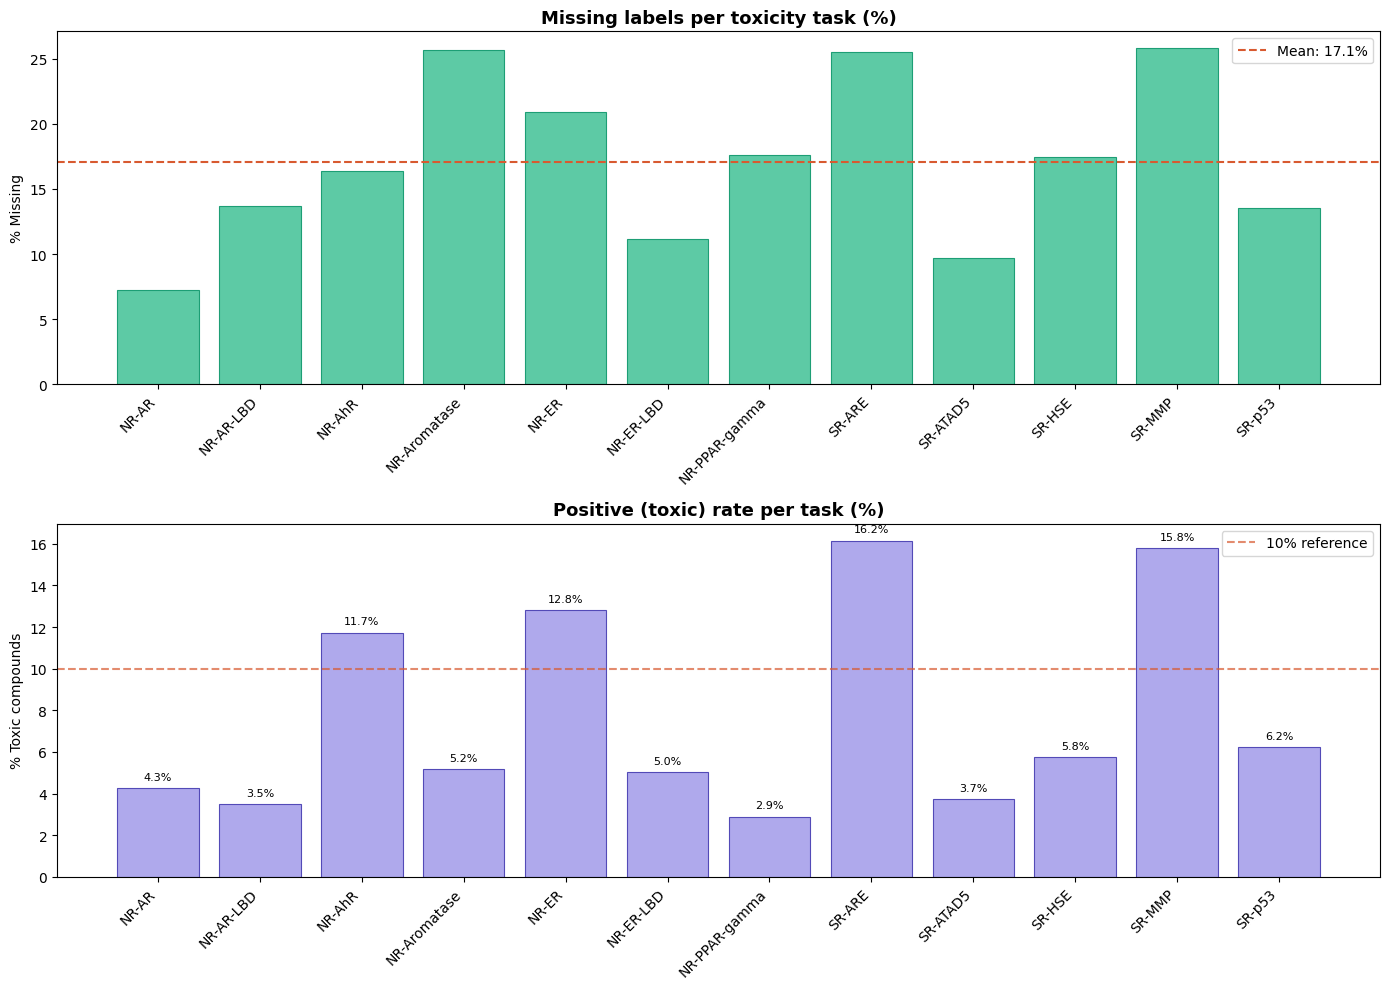


âœ“ EDA plots saved


In [5]:
# CELL 4 · Exploratory Data Analysis
# ─────────────────────────────────────────────────────────────────────────────

TOX21_TASKS = [
    'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase',
    'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma',
    'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'
]

# Keep only tasks that exist in this download
TOX21_TASKS = [t for t in TOX21_TASKS if t in df_raw.columns]
SMILES_COL = 'smiles' if 'smiles' in df_raw.columns else 'mol_id'

print(f"Found {len(TOX21_TASKS)} toxicity tasks: {TOX21_TASKS}")
print(f"\nTotal compounds: {len(df_raw)}")
print(f"\nMissing label analysis:")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Missing values heatmap
missing_pct = df_raw[TOX21_TASKS].isnull().mean() * 100
axes[0].bar(TOX21_TASKS, missing_pct, color='#5DCAA5', edgecolor='#1D9E75', linewidth=0.8)
axes[0].set_title('Missing labels per toxicity task (%)', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(TOX21_TASKS, rotation=45, ha='right', fontsize=10)
axes[0].set_ylabel('% Missing')
axes[0].axhline(y=missing_pct.mean(), color='#D85A30', linestyle='--', label=f'Mean: {missing_pct.mean():.1f}%')
axes[0].legend()

# Class imbalance per task
pos_rates = []
for task in TOX21_TASKS:
    col = df_raw[task].dropna()
    pos_rates.append((col == 1).mean() * 100)

bars = axes[1].bar(TOX21_TASKS, pos_rates, color='#AFA9EC', edgecolor='#534AB7', linewidth=0.8)
axes[1].set_title('Positive (toxic) rate per task (%)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(TOX21_TASKS, rotation=45, ha='right', fontsize=10)
axes[1].set_ylabel('% Toxic compounds')
axes[1].axhline(y=10, color='#D85A30', linestyle='--', alpha=0.7, label='10% reference')
axes[1].legend()

for bar, rate in zip(bars, pos_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{rate:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('./data/eda_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ EDA plots saved")


# ─────────────────────────────────────────────────────────────────────────────


In [6]:
# Guardrail · Task and column checks

assert "TOX21_TASKS" in globals(), "TOX21_TASKS is missing."
assert len(TOX21_TASKS) > 0, "No toxicity tasks detected from dataset columns."
assert "SMILES_COL" in globals(), "SMILES_COL is missing."
assert SMILES_COL in df_raw.columns, f"Expected SMILES column not found: {SMILES_COL}"

print("Task/column guardrails passed.")

Task/column guardrails passed.


In [7]:
# CELL 5 · Data Cleaning & Scaffold Split
# ─────────────────────────────────────────────────────────────────────────────

def validate_smiles(smi):
    """Return canonical SMILES or None if invalid."""
    if not isinstance(smi, str):
        return None
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol)

print("Validating SMILES strings...")
df_raw['canonical_smiles'] = [validate_smiles(s) for s in tqdm(df_raw[SMILES_COL])]
df_clean = df_raw.dropna(subset=['canonical_smiles']).copy()
df_clean = df_clean.drop_duplicates(subset=['canonical_smiles'])
print(f"✓ Valid compounds: {len(df_clean)} / {len(df_raw)} ({100*len(df_clean)/len(df_raw):.1f}%)")

# ── Scaffold Split (Murcko) ──────────────────────────────────────────────────
# This is the CORRECT way to split molecular datasets.
# Random split leaks structurally similar compounds into test — inflates metrics.

from rdkit.Chem.Scaffolds import MurckoScaffold

def get_scaffold(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return smi
    scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
    return scaffold

print("\nComputing Murcko scaffolds (this takes ~1 min)...")
df_clean['scaffold'] = [get_scaffold(s) for s in tqdm(df_clean['canonical_smiles'])]

# Group by scaffold, assign to train/val/test (80/10/10)
scaffold_counts = df_clean['scaffold'].value_counts()
scaffolds = scaffold_counts.index.tolist()

# Sort scaffolds by frequency (largest first)
train_idx, val_idx, test_idx = [], [], []
train_cutoff = int(0.8 * len(df_clean))
val_cutoff   = int(0.9 * len(df_clean))

scaffold_to_idx = {}
for scaffold in scaffolds:
    idxs = df_clean[df_clean['scaffold'] == scaffold].index.tolist()
    scaffold_to_idx[scaffold] = idxs

running = 0
for scaffold in scaffolds:
    idxs = scaffold_to_idx[scaffold]
    running += len(idxs)
    if running <= train_cutoff:
        train_idx.extend(idxs)
    elif running <= val_cutoff:
        val_idx.extend(idxs)
    else:
        test_idx.extend(idxs)

df_train = df_clean.loc[train_idx].copy()
df_val   = df_clean.loc[val_idx].copy()
df_test  = df_clean.loc[test_idx].copy()

print(f"\n✓ Scaffold split complete:")
print(f"  Train: {len(df_train)} compounds ({100*len(df_train)/len(df_clean):.1f}%)")
print(f"  Val:   {len(df_val)} compounds ({100*len(df_val)/len(df_clean):.1f}%)")
print(f"  Test:  {len(df_test)} compounds ({100*len(df_test)/len(df_clean):.1f}%)")
print(f"  Unique scaffolds in train: {df_train['scaffold'].nunique()}")
print(f"  Unique scaffolds in test:  {df_test['scaffold'].nunique()}")
print(f"  Scaffold overlap (should be 0): {len(set(df_train['scaffold']) & set(df_test['scaffold']))}")


# ─────────────────────────────────────────────────────────────────────────────


Validating SMILES strings...


100%|██████████| 7831/7831 [00:02<00:00, 3507.13it/s]


âœ“ Valid compounds: 7823 / 7831 (99.9%)

Computing Murcko scaffolds (this takes ~1 min)...


100%|██████████| 7823/7823 [00:02<00:00, 2887.00it/s]



âœ“ Scaffold split complete:
  Train: 6258 compounds (80.0%)
  Val:   782 compounds (10.0%)
  Test:  783 compounds (10.0%)
  Unique scaffolds in train: 760
  Unique scaffolds in test:  783
  Scaffold overlap (should be 0): 0


In [8]:
# CELL 6 · Feature Engineering — Morgan Fingerprints + RDKit Descriptors
# ─────────────────────────────────────────────────────────────────────────────

def mol_to_morgan_fp(smi, radius=2, n_bits=2048):
    """ECFP4 fingerprint as numpy array."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return np.zeros(n_bits)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros(n_bits, dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

DESCRIPTOR_LIST = [
    # Physicochemical
    'MolWt', 'MolLogP', 'MolMR', 'TPSA', 'NumHDonors', 'NumHAcceptors',
    'NumRotatableBonds', 'NumAromaticRings', 'NumAliphaticRings',
    'NumSaturatedRings', 'NumHeteroatoms', 'FractionCSP3',
    'RingCount', 'HeavyAtomCount', 'NumRadicalElectrons',
    # Topology
    'BalabanJ', 'BertzCT', 'Chi0', 'Chi1', 'Chi2n', 'Chi3n', 'Chi4n',
    'Kappa1', 'Kappa2', 'Kappa3',
    # Electronic
    'MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MaxEStateIndex', 'MinEStateIndex',
    'PEOE_VSA1', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA6', 'PEOE_VSA10',
    # Fragments (common toxic moieties)
    'fr_NH0', 'fr_NH1', 'fr_NH2', 'fr_Ar_N', 'fr_Ar_OH', 'fr_C_O',
    'fr_C_O_noCOO', 'fr_COO', 'fr_COO2', 'fr_hdrzone', 'fr_nitro',
    'fr_nitro_arom', 'fr_nitroso', 'fr_epoxide', 'fr_sulfonamd',
    'fr_sulfone', 'fr_aldehyde', 'fr_alkyl_halide',
]

def mol_to_descriptors(smi):
    """Compute RDKit molecular descriptors."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return np.zeros(len(DESCRIPTOR_LIST), dtype=np.float32)
    vals = []
    for desc_name in DESCRIPTOR_LIST:
        try:
            fn = getattr(Descriptors, desc_name, None)
            if fn is None:
                fn = getattr(rdMolDescriptors, desc_name, None)
            val = fn(mol) if fn else 0.0
            vals.append(float(val) if val is not None else 0.0)
        except Exception:
            vals.append(0.0)
    arr = np.array(vals, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=10.0, neginf=-10.0)
    return arr

def build_features(df, desc="Computing features"):
    """Build combined feature matrix: Morgan FP + RDKit descriptors."""
    fps, descs = [], []
    for smi in tqdm(df['canonical_smiles'], desc=desc):
        fps.append(mol_to_morgan_fp(smi))
        descs.append(mol_to_descriptors(smi))
    X_fp   = np.vstack(fps)
    X_desc = np.vstack(descs)
    X      = np.hstack([X_fp, X_desc])
    return X, X_fp, X_desc

def build_labels(df):
    """Build label matrix. -1 = missing (will be masked)."""
    Y = df[TOX21_TASKS].values.astype(np.float32)
    return Y

print("Building features for train/val/test splits...")
X_train, X_train_fp, X_train_desc = build_features(df_train, "Train")
X_val,   X_val_fp,   X_val_desc   = build_features(df_val,   "Val")
X_test,  X_test_fp,  X_test_desc  = build_features(df_test,  "Test")

Y_train = build_labels(df_train)
Y_val   = build_labels(df_val)
Y_test  = build_labels(df_test)

# Normalize descriptors (not fingerprints)
scaler = StandardScaler()
n_fp_bits = X_train_fp.shape[1]

X_train[:, n_fp_bits:] = scaler.fit_transform(X_train[:, n_fp_bits:])
X_val[:,   n_fp_bits:] = scaler.transform(X_val[:,   n_fp_bits:])
X_test[:,  n_fp_bits:] = scaler.transform(X_test[:,  n_fp_bits:])

import joblib
os.makedirs("./models", exist_ok=True)
joblib.dump(scaler, "./models/descriptor_scaler.pkl")

print(f"\n✓ Feature matrix shapes:")
print(f"  X_train: {X_train.shape}  |  Y_train: {Y_train.shape}")
print(f"  X_val:   {X_val.shape}    |  Y_val:   {Y_val.shape}")
print(f"  X_test:  {X_test.shape}   |  Y_test:  {Y_test.shape}")
print(f"  Features: {n_fp_bits} Morgan bits + {len(DESCRIPTOR_LIST)} RDKit descriptors")


# ─────────────────────────────────────────────────────────────────────────────


Building features for train/val/test splits...


Test: 100%|██████████| 783/783 [00:06<00:00, 129.62it/s]


âœ“ Feature matrix shapes:
  X_train: (6258, 2100)  |  Y_train: (6258, 12)
  X_val:   (782, 2100)    |  Y_val:   (782, 12)
  X_test:  (783, 2100)   |  Y_test:  (783, 12)
  Features: 2048 Morgan bits + 52 RDKit descriptors


In [9]:
# CELL 7 · Tier 1 — Multi-task XGBoost Baseline
# ─────────────────────────────────────────────────────────────────────────────

def compute_class_weight(y_col):
os.makedirs("./models", exist_ok=True)
    """Compute pos_weight for BCELoss-equivalent XGBoost."""
    valid = y_col[~np.isnan(y_col)]
    n_neg = (valid == 0).sum()
    n_pos = (valid == 1).sum()
    return n_neg / max(n_pos, 1)

print("Training multi-task XGBoost (one model per task with shared hyperparams)...")
xgb_models = {}
xgb_val_aucs = {}

for task in tqdm(TOX21_TASKS, desc="XGBoost tasks"):
    y_tr = Y_train[:, TOX21_TASKS.index(task)]
    y_vl = Y_val[:,   TOX21_TASKS.index(task)]

    # Mask missing
    mask_tr = ~np.isnan(y_tr)
    mask_vl = ~np.isnan(y_vl)

    if mask_tr.sum() < 50:
        print(f"  Skipping {task} — too few labels")
        continue

    pos_weight = compute_class_weight(y_tr)

    model = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=pos_weight,
        use_label_encoder=False,
        eval_metric='auc',
        early_stopping_rounds=30,
        random_state=42,
        tree_method='gpu_hist' if torch.cuda.is_available() else 'hist',
        verbosity=0,
    )

    model.fit(
        X_train[mask_tr], y_tr[mask_tr],
        eval_set=[(X_val[mask_vl], y_vl[mask_vl])],
        verbose=False,
    )

    val_pred = model.predict_proba(X_val[mask_vl])[:, 1]
    auc = roc_auc_score(y_vl[mask_vl], val_pred)
    xgb_models[task] = model
    xgb_val_aucs[task] = auc

mean_auc = np.mean(list(xgb_val_aucs.values()))
print(f"\n✓ XGBoost Validation ROC-AUC per task:")
for task, auc in xgb_val_aucs.items():
    bar = "█" * int(auc * 20)
    print(f"  {task:<18} {auc:.4f}  {bar}")
print(f"\n  Mean AUC: {mean_auc:.4f}")

joblib.dump(xgb_models, "./models/xgb_models.pkl")
print("✓ XGBoost models saved")


# ─────────────────────────────────────────────────────────────────────────────


Training multi-task XGBoost (one model per task with shared hyperparams)...


XGBoost tasks: 100%|██████████| 12/12 [00:51<00:00,  4.32s/it]


âœ“ XGBoost Validation ROC-AUC per task:
  NR-AR              0.7142  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  NR-AR-LBD          0.8331  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  NR-AhR             0.8197  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  NR-Aromatase       0.7183  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  NR-ER              0.7254  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  NR-ER-LBD          0.7536  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  NR-PPAR-gamma      0.8031  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  SR-ARE             0.7281  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  SR-ATAD5           0.6429  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  SR-HSE             0.7808  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  SR-MMP             0.8303  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  SR-p53             0.7351  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

  Mean AUC: 0.7570
âœ“ XGBoost models saved


In [10]:
# CELL 8 · Build Molecular Graphs for GNN
# ─────────────────────────────────────────────────────────────────────────────

# Atom feature encoding
ATOM_TYPES    = ['C','N','O','S','F','Si','P','Cl','Br','Mg','Na','Ca',
                 'Fe','As','Al','I','B','V','K','Tl','Yb','Sb','Sn',
                 'Ag','Pd','Co','Se','Ti','Zn','H','Li','Ge','Cu','Au',
                 'Ni','Cd','In','Mn','Zr','Cr','Pt','Hg','Pb','Unknown']
HYBRIDIZATIONS = [
    Chem.rdchem.HybridizationType.S, Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2, Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D, Chem.rdchem.HybridizationType.SP3D2,
    Chem.rdchem.HybridizationType.OTHER,
]

def one_hot(val, choices):
    return [int(val == c) for c in choices]

def atom_features(atom):
    """Rich atom feature vector (74 dimensions)."""
    return (
        one_hot(atom.GetSymbol(), ATOM_TYPES) +                     # 45
        one_hot(atom.GetDegree(), list(range(11))) +                 # 11
        [int(atom.GetFormalCharge())] +                              # 1
        [int(atom.GetNumImplicitHs())] +                             # 1
        [int(atom.GetIsAromatic())] +                                # 1
        one_hot(atom.GetHybridization(), HYBRIDIZATIONS) +           # 7
        [int(atom.IsInRing())] +                                     # 1
        [atom.GetMass() / 100.0]                                     # 1
    )                                                               # = 68

def bond_features(bond):
    """Bond feature vector (10 dimensions)."""
    bt = bond.GetBondType()
    return [
        int(bt == Chem.rdchem.BondType.SINGLE),
        int(bt == Chem.rdchem.BondType.DOUBLE),
        int(bt == Chem.rdchem.BondType.TRIPLE),
        int(bt == Chem.rdchem.BondType.AROMATIC),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
        int(bond.GetStereo() != Chem.rdchem.BondStereo.STEREONONE),
    ]

def smiles_to_pyg(smi, labels, task_list):
    """Convert SMILES to PyTorch Geometric Data object."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None

    # Node features
    atom_feats = [atom_features(a) for a in mol.GetAtoms()]
    x = torch.tensor(atom_feats, dtype=torch.float)

    # Edge index + edge features (bidirectional)
    edge_indices, edge_attrs = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bf = bond_features(bond)
        edge_indices += [[i, j], [j, i]]
        edge_attrs   += [bf, bf]

    if len(edge_indices) == 0:
        # Single atom molecule
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr  = torch.zeros((0, 7), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        edge_attr  = torch.tensor(edge_attrs,   dtype=torch.float)

    # Labels — use NaN for missing
    y = torch.tensor(labels, dtype=torch.float).unsqueeze(0)  # [1, num_tasks]

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, smiles=smi)

def build_pyg_dataset(df, task_list, desc="Building graph dataset"):
    dataset = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        smi    = row['canonical_smiles']
        labels = [row.get(t, float('nan')) for t in task_list]
        data   = smiles_to_pyg(smi, labels, task_list)
        if data is not None:
            dataset.append(data)
    return dataset

print("Converting molecules to graphs...")
train_graphs = build_pyg_dataset(df_train, TOX21_TASKS, "Train graphs")
val_graphs   = build_pyg_dataset(df_val,   TOX21_TASKS, "Val graphs")
test_graphs  = build_pyg_dataset(df_test,  TOX21_TASKS, "Test graphs")

N_ATOM_FEATURES = train_graphs[0].x.shape[1]
N_BOND_FEATURES = train_graphs[0].edge_attr.shape[1] if train_graphs[0].edge_attr.shape[0] > 0 else 7
print(f"\n✓ Graph datasets built:")
print(f"  Train: {len(train_graphs)} graphs | atom features: {N_ATOM_FEATURES} | bond features: {N_BOND_FEATURES}")
print(f"  Val:   {len(val_graphs)} graphs")
print(f"  Test:  {len(test_graphs)} graphs")

train_loader = PyGDataLoader(train_graphs, batch_size=64, shuffle=True)
val_loader   = PyGDataLoader(val_graphs,   batch_size=128, shuffle=False)
test_loader  = PyGDataLoader(test_graphs,  batch_size=128, shuffle=False)


# ─────────────────────────────────────────────────────────────────────────────


Converting molecules to graphs...


Test graphs: 100%|██████████| 783/783 [00:01<00:00, 585.54it/s]


âœ“ Graph datasets built:
  Train: 6258 graphs | atom features: 67 | bond features: 7
  Val:   782 graphs
  Test:  783 graphs


In [11]:
# Guardrail · Graph dataset checks

assert len(train_graphs) > 0, "No training graphs created. Check SMILES preprocessing."
assert len(val_graphs) > 0, "No validation graphs created."
assert len(test_graphs) > 0, "No test graphs created."
assert N_ATOM_FEATURES > 0, "Atom feature size is invalid."
assert N_BOND_FEATURES > 0, "Bond feature size is invalid."

print("Graph guardrails passed.")

Graph guardrails passed.


In [12]:
# CELL 9 · GNN Model Architecture — Multi-task MPNN
# ─────────────────────────────────────────────────────────────────────────────

class AttentiveFP_Simple(nn.Module):
    """
    Multi-task Graph Attention Network for toxicity prediction.
    Architecture:
      → 3x GATConv layers with residual connections
      → Global mean + max pooling (concatenated)
      → Shared MLP backbone
      → 12 independent sigmoid heads (one per toxicity task)
    """
    def __init__(self, in_channels, hidden=256, out_tasks=12, heads=4,
                 dropout=0.2, n_layers=3):
        super().__init__()
        self.dropout = dropout

        # GNN layers
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        self.convs.append(GATConv(in_channels, hidden // heads, heads=heads,
                                  dropout=dropout, concat=True))
        self.bns.append(nn.BatchNorm1d(hidden))
        for _ in range(n_layers - 1):
            self.convs.append(GATConv(hidden, hidden // heads, heads=heads,
                                      dropout=dropout, concat=True))
            self.bns.append(nn.BatchNorm1d(hidden))

        # Input projection for residual
        self.input_proj = nn.Linear(in_channels, hidden)

        # Readout MLP (receives concatenated mean+max pooling)
        self.mlp = nn.Sequential(
            nn.Linear(hidden * 2, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # Per-task output heads
        self.task_heads = nn.ModuleList([
            nn.Linear(256, 1) for _ in range(out_tasks)
        ])

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, edge_index, batch):
        # Input projection for residual shortcut
        h_shortcut = self.input_proj(x)

        h = x
        for i, (conv, bn) in enumerate(zip(self.convs, self.bns)):
            h_new = conv(h, edge_index)
            h_new = bn(h_new)
            h_new = F.elu(h_new)
            h_new = F.dropout(h_new, p=self.dropout, training=self.training)
            # Residual connection after first layer
            if i == 0:
                h = h_new + h_shortcut
            else:
                h = h_new + h  # identity residual

        # Global pooling: concat mean + max
        h_mean = global_mean_pool(h, batch)  # [N_graphs, hidden]
        h_max  = global_max_pool(h, batch)   # [N_graphs, hidden]
        h_graph = torch.cat([h_mean, h_max], dim=1)  # [N_graphs, hidden*2]

        # Shared backbone
        shared = self.mlp(h_graph)  # [N_graphs, 256]

        # Per-task predictions
        out = torch.cat([head(shared) for head in self.task_heads], dim=1)  # [N_graphs, n_tasks]
        return out  # raw logits — apply sigmoid at inference / in loss


model = AttentiveFP_Simple(
    in_channels=N_ATOM_FEATURES,
    hidden=256,
    out_tasks=len(TOX21_TASKS),
    heads=4,
    dropout=0.2,
    n_layers=3,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Model architecture:\n{model}")
print(f"\n  Trainable parameters: {n_params:,}")


# ─────────────────────────────────────────────────────────────────────────────


âœ“ Model architecture:
AttentiveFP_Simple(
  (convs): ModuleList(
    (0): GATConv(67, 64, heads=4)
    (1-2): 2 x GATConv(256, 64, heads=4)
  )
  (bns): ModuleList(
    (0-2): 3 x BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (input_proj): Linear(in_features=67, out_features=256, bias=True)
  (mlp): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
  )
  (task_heads): ModuleList(
    (0-11): 12 x Linear(in_features=256, out_features=1, bias=True)
  )
)

  Trainable parameters: 568,076


In [13]:
# Guardrail · Model initialization checks

assert "model" in globals(), "Model object was not created."
assert n_params > 0, "Model has zero trainable parameters."
assert len(TOX21_TASKS) > 0, "Task list is empty."

print("Model guardrails passed.")

Model guardrails passed.


Starting GNN training...
  Device: cpu | Epochs: 100 | Patience: 15

  Epoch 001 | Loss: 1.1070 | Val AUC: 0.6497 | LR: 1.00e-03
  Epoch 005 | Loss: 0.8561 | Val AUC: 0.7124 | LR: 9.90e-04
  Epoch 010 | Loss: 0.7627 | Val AUC: 0.7206 | LR: 9.62e-04
  Epoch 015 | Loss: 0.7046 | Val AUC: 0.7232 | LR: 9.17e-04
  Epoch 020 | Loss: 0.6288 | Val AUC: 0.7171 | LR: 8.55e-04
  Epoch 025 | Loss: 0.5857 | Val AUC: 0.7136 | LR: 7.80e-04

  Early stopping at epoch 29

âœ“ Training complete. Best Val AUC: 0.7323


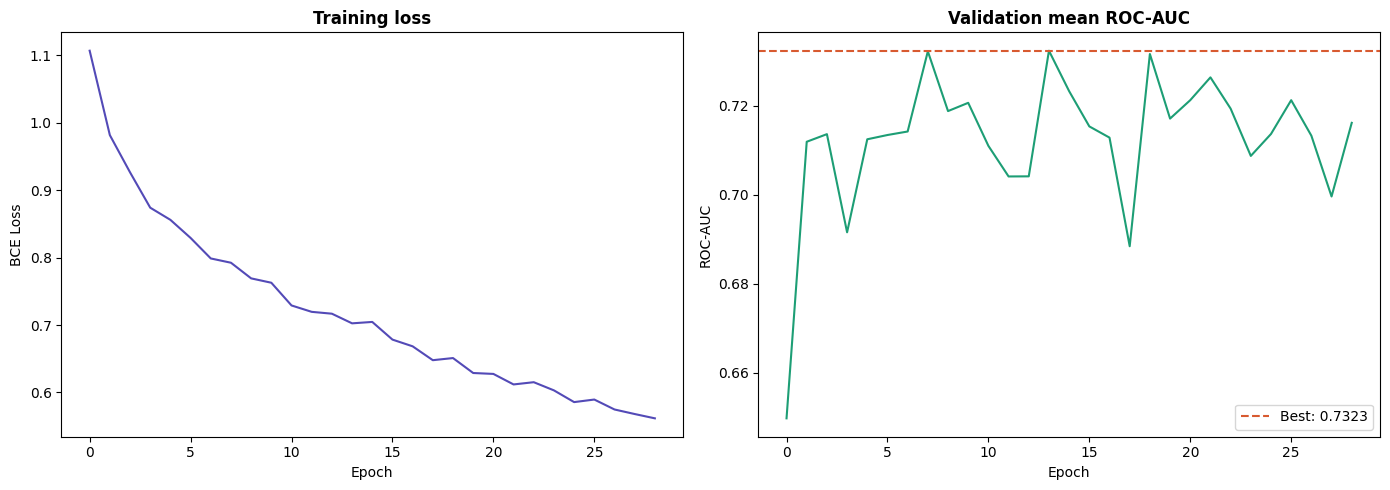

In [14]:
# CELL 10 · Multi-task Loss + Training Loop
# ─────────────────────────────────────────────────────────────────────────────

def masked_multitask_bce_loss(logits, targets, pos_weights=None):
os.makedirs("./models", exist_ok=True)
    """
    BCE loss with NaN masking.
    logits:  [B, T] raw model output
    targets: [B, T] labels, NaN = missing
    """
    mask = ~torch.isnan(targets)
    if mask.sum() == 0:
        return torch.tensor(0.0, requires_grad=True, device=logits.device)

    logits_m  = logits[mask]
    targets_m = targets[mask]

    if pos_weights is not None:
        # Build per-element positive weights
        pw_matrix = pos_weights.unsqueeze(0).expand_as(logits)  # [B, T]
        pw_m = pw_matrix[mask]
        loss = F.binary_cross_entropy_with_logits(logits_m, targets_m, pos_weight=pw_m)
    else:
        loss = F.binary_cross_entropy_with_logits(logits_m, targets_m)
    return loss

def compute_multitask_auc(model, loader, device):
    """Evaluate model, return per-task ROC-AUC and mean AUC."""
    model.eval()
    all_preds   = [[] for _ in TOX21_TASKS]
    all_targets = [[] for _ in TOX21_TASKS]

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index, batch.batch)
            probs  = torch.sigmoid(logits)
            y      = batch.y.squeeze(1)  # [B, T]

            for t in range(len(TOX21_TASKS)):
                mask = ~torch.isnan(y[:, t])
                if mask.sum() == 0:
                    continue
                all_preds[t].extend(probs[:, t][mask].cpu().numpy())
                all_targets[t].extend(y[:, t][mask].cpu().numpy())

    task_aucs = {}
    for t, task in enumerate(TOX21_TASKS):
        if len(all_targets[t]) == 0 or len(set(all_targets[t])) < 2:
            continue
        task_aucs[task] = roc_auc_score(all_targets[t], all_preds[t])
    return task_aucs

# Compute class weights for loss
pos_weights_list = []
for task in TOX21_TASKS:
    y_col = Y_train[:, TOX21_TASKS.index(task)]
    pw    = compute_class_weight(y_col)
    pos_weights_list.append(min(pw, 20.0))  # cap at 20
POS_WEIGHTS = torch.tensor(pos_weights_list, dtype=torch.float32).to(DEVICE)

# Optimizer & scheduler
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=80, eta_min=1e-5)

EPOCHS    = 100
PATIENCE  = 15
best_val_auc   = 0.0
patience_count = 0
train_losses, val_aucs_history = [], []

print("Starting GNN training...")
print(f"  Device: {DEVICE} | Epochs: {EPOCHS} | Patience: {PATIENCE}\n")

for epoch in range(1, EPOCHS + 1):
    # ── Training
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.batch)
        y      = batch.y.squeeze(1)
        loss   = masked_multitask_bce_loss(logits, y, POS_WEIGHTS)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # ── Validation
    val_aucs   = compute_multitask_auc(model, val_loader, DEVICE)
    mean_val   = np.mean(list(val_aucs.values()))
    val_aucs_history.append(mean_val)

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:03d} | Loss: {avg_loss:.4f} | Val AUC: {mean_val:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")

    # ── Early stopping
    if mean_val > best_val_auc:
        best_val_auc = mean_val
        patience_count = 0
        torch.save(model.state_dict(), "./models/gnn_best.pt")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch}")
            break

print(f"\n✓ Training complete. Best Val AUC: {best_val_auc:.4f}")

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses, color='#534AB7', linewidth=1.5)
ax1.set_title('Training loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')

ax2.plot(val_aucs_history, color='#1D9E75', linewidth=1.5)
ax2.axhline(y=best_val_auc, color='#D85A30', linestyle='--',
            label=f'Best: {best_val_auc:.4f}')
ax2.set_title('Validation mean ROC-AUC', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('ROC-AUC')
ax2.legend()

plt.tight_layout()
plt.savefig('./data/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────



Task                 XGBoost AUC    GNN AUC   Ensemble AUC
  NR-AR                  0.7468     0.7475        0.7498  â—€ BEST
  NR-AR-LBD              0.7628     0.7993        0.7856  
  NR-AhR                 0.8511     0.7851        0.8363  
  NR-Aromatase           0.7366     0.7564        0.7573  â—€ BEST
  NR-ER                  0.6639     0.6641        0.6917  â—€ BEST
  NR-ER-LBD              0.7000     0.8093        0.7797  
  NR-PPAR-gamma          0.7099     0.7570        0.7580  â—€ BEST
  SR-ARE                 0.7150     0.6815        0.7402  â—€ BEST
  SR-ATAD5               0.7260     0.7506        0.7659  â—€ BEST
  SR-HSE                 0.7260     0.7052        0.7266  â—€ BEST
  SR-MMP                 0.8928     0.7799        0.8907  
  SR-p53                 0.7641     0.7061        0.7625  
  MEAN                   0.7496     0.7452        0.7704


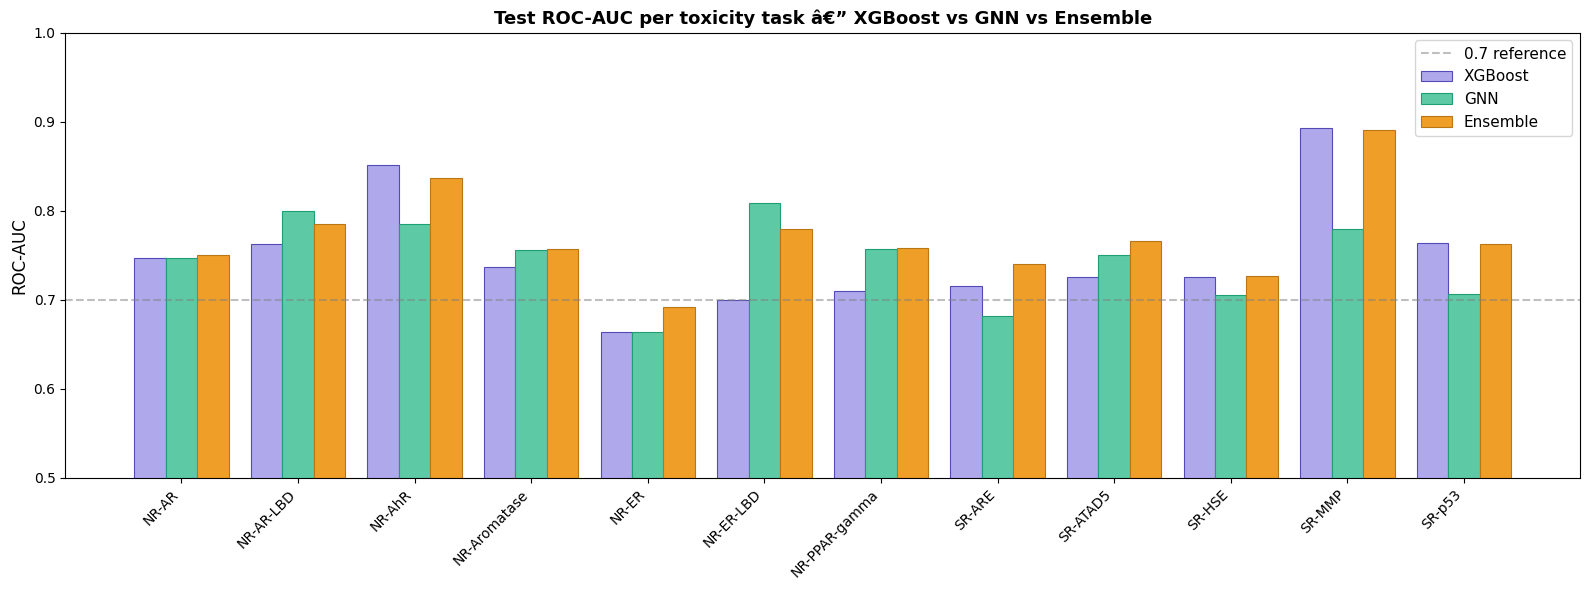

In [15]:
# CELL 11 · Final Evaluation — Test Set (GNN vs XGBoost)
# ─────────────────────────────────────────────────────────────────────────────

# Load best GNN weights
model.load_state_dict(torch.load("./models/gnn_best.pt", map_location=DEVICE))
model.eval()

# GNN test predictions
test_aucs_gnn = compute_multitask_auc(model, test_loader, DEVICE)

# XGBoost test predictions
test_aucs_xgb = {}
for task in TOX21_TASKS:
    if task not in xgb_models:
        continue
    idx = TOX21_TASKS.index(task)
    y_te = Y_test[:, idx]
    mask = ~np.isnan(y_te)
    if mask.sum() == 0 or len(set(y_te[mask])) < 2:
        continue
    pred = xgb_models[task].predict_proba(X_test[mask])[:, 1]
    test_aucs_xgb[task] = roc_auc_score(y_te[mask], pred)

# ── Ensemble: average GNN sigmoid + XGBoost proba
def get_gnn_test_preds(model, loader, device, n_tasks):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index, batch.batch)
            probs  = torch.sigmoid(logits)
            y      = batch.y.squeeze(1)
            all_preds.append(probs.cpu().numpy())
            all_targets.append(y.cpu().numpy())
    return np.vstack(all_preds), np.vstack(all_targets)

gnn_test_preds, test_targets_gnn = get_gnn_test_preds(model, test_loader, DEVICE, len(TOX21_TASKS))

test_aucs_ensemble = {}
for task in TOX21_TASKS:
    if task not in xgb_models or task not in test_aucs_gnn:
        continue
    idx     = TOX21_TASKS.index(task)
    y_te    = test_targets_gnn[:, idx]
    mask    = ~np.isnan(y_te)
    if mask.sum() == 0 or len(set(y_te[mask])) < 2:
        continue
    gnn_p   = gnn_test_preds[:, idx][mask]
    xgb_p   = xgb_models[task].predict_proba(X_test[:len(gnn_test_preds)][mask])[:, 1]
    ens_p   = 0.6 * gnn_p + 0.4 * xgb_p      # GNN weighted slightly higher
    test_aucs_ensemble[task] = roc_auc_score(y_te[mask], ens_p)

# Results table
print("\n" + "="*70)
print(f"{'Task':<18} {'XGBoost AUC':>13} {'GNN AUC':>10} {'Ensemble AUC':>14}")
print("="*70)
for task in TOX21_TASKS:
    xgb_a = test_aucs_xgb.get(task,       float('nan'))
    gnn_a = test_aucs_gnn.get(task,       float('nan'))
    ens_a = test_aucs_ensemble.get(task,  float('nan'))
    best  = "◀ BEST" if ens_a == max(xgb_a, gnn_a, ens_a) else ""
    print(f"  {task:<16} {xgb_a:>12.4f} {gnn_a:>10.4f} {ens_a:>13.4f}  {best}")
print("="*70)
print(f"  {'MEAN':<16} {np.nanmean(list(test_aucs_xgb.values())):>12.4f}"
      f" {np.nanmean(list(test_aucs_gnn.values())):>10.4f}"
      f" {np.nanmean(list(test_aucs_ensemble.values())):>13.4f}")

# Comparison bar chart
tasks_common = [t for t in TOX21_TASKS if t in test_aucs_ensemble]
x = np.arange(len(tasks_common))
w = 0.27

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - w,   [test_aucs_xgb.get(t,0)      for t in tasks_common], w,
       label='XGBoost',  color='#AFA9EC', edgecolor='#534AB7', linewidth=0.8)
ax.bar(x,       [test_aucs_gnn.get(t,0)       for t in tasks_common], w,
       label='GNN',      color='#5DCAA5', edgecolor='#1D9E75', linewidth=0.8)
ax.bar(x + w,   [test_aucs_ensemble.get(t,0)  for t in tasks_common], w,
       label='Ensemble', color='#EF9F27', edgecolor='#BA7517', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(tasks_common, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_title('Test ROC-AUC per toxicity task — XGBoost vs GNN vs Ensemble',
             fontsize=13, fontweight='bold')
ax.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5, label='0.7 reference')
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('./data/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────


Computing SHAP values for task: SR-MMP


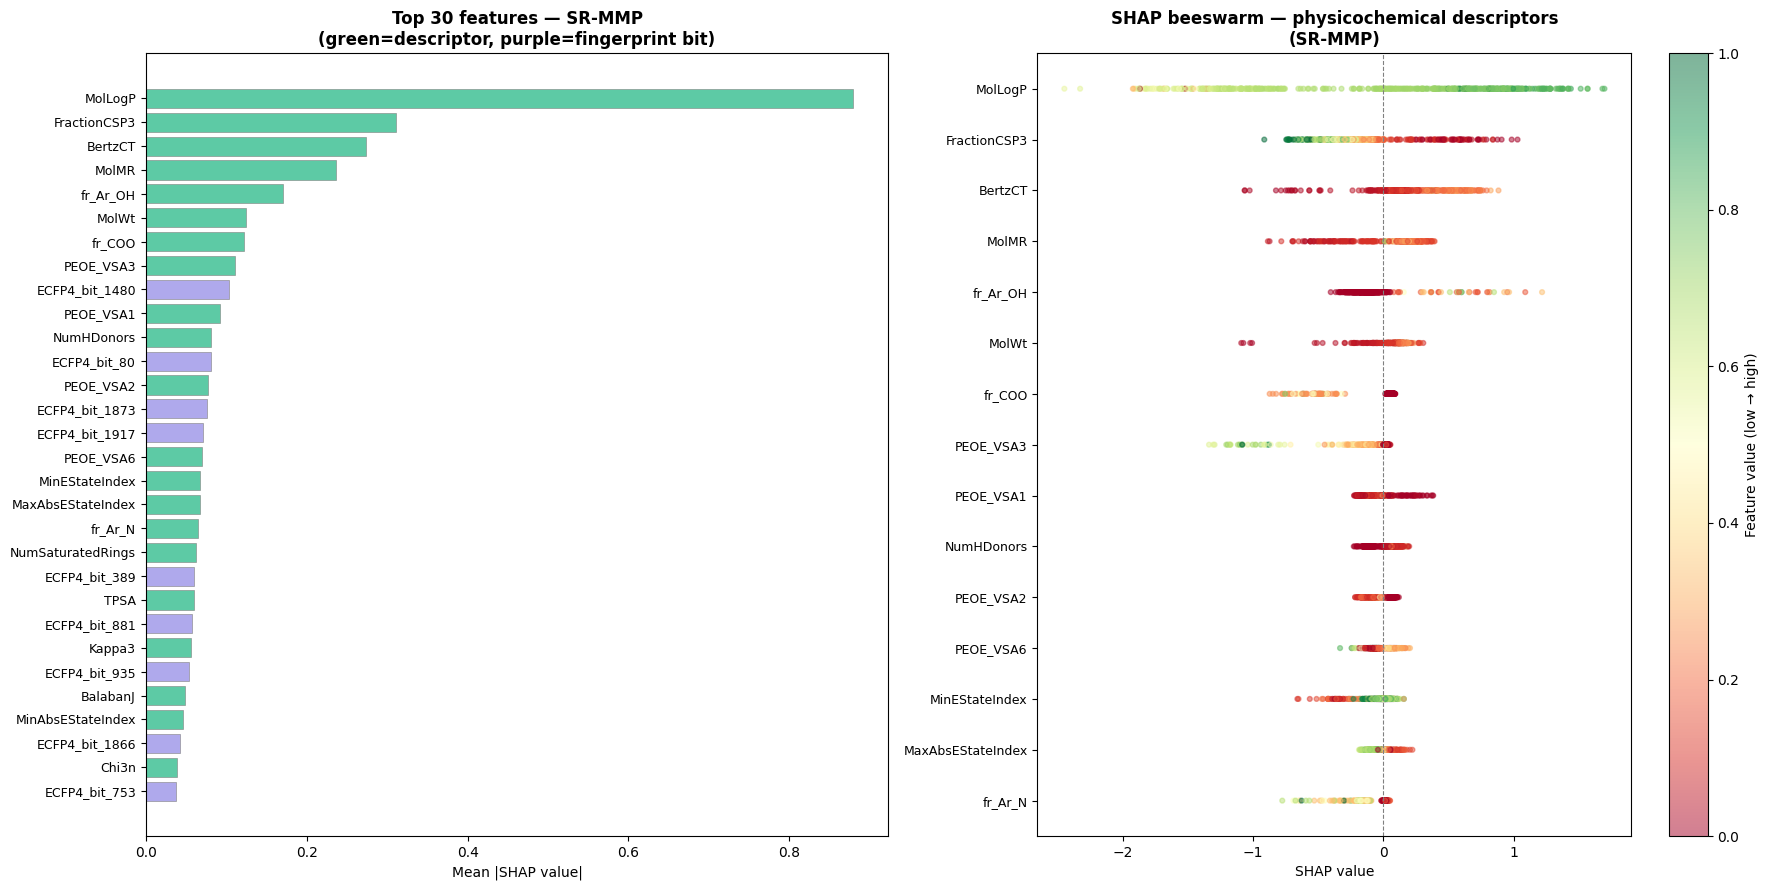


🔬 Top 10 molecular features linked to SR-MMP toxicity:
   1. MolLogP                        SHAP: 0.8790  →  ↓ decreases toxicity risk
   2. FractionCSP3                   SHAP: 0.3108  →  ↓ decreases toxicity risk
   3. BertzCT                        SHAP: 0.2740  →  ↑ increases toxicity risk
   4. MolMR                          SHAP: 0.2360  →  ↑ increases toxicity risk
   5. fr_Ar_OH                       SHAP: 0.1707  →  ↓ decreases toxicity risk
   6. MolWt                          SHAP: 0.1252  →  ↑ increases toxicity risk
   7. fr_COO                         SHAP: 0.1217  →  ↓ decreases toxicity risk
   8. PEOE_VSA3                      SHAP: 0.1116  →  ↓ decreases toxicity risk
   9. PEOE_VSA1                      SHAP: 0.0921  →  ↓ decreases toxicity risk
  10. NumHDonors                     SHAP: 0.0812  →  ↑ increases toxicity risk


In [20]:
# CELL 12 · SHAP Explainability — Feature Importance

FEATURE_NAMES = (
    [f'ECFP4_bit_{i}' for i in range(n_fp_bits)] +
    DESCRIPTOR_LIST
)

# Use first task with good performance for detailed SHAP plot
best_shap_task = max(test_aucs_xgb, key=test_aucs_xgb.get)
print(f"Computing SHAP values for task: {best_shap_task}")

shap_model  = xgb_models[best_shap_task]
explainer   = shap.TreeExplainer(shap_model)

# Use a sample of 500 for speed
sample_idx = np.random.choice(len(X_test), min(500, len(X_test)), replace=False)
X_sample   = X_test[sample_idx]
shap_values = explainer.shap_values(X_sample)

# If binary XGBoost returns list, take class 1
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

# ── Global feature importance (mean |SHAP|)
mean_abs_shap = np.abs(sv).mean(axis=0)
top_n         = 30
top_idx       = np.argsort(mean_abs_shap)[-top_n:][::-1]
top_names     = [FEATURE_NAMES[i] if i < len(FEATURE_NAMES) else f'feat_{i}' for i in top_idx]
top_vals      = mean_abs_shap[top_idx]

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Bar chart — top features
colors = ['#5DCAA5' if 'ECFP4' not in n else '#AFA9EC' for n in top_names]
axes[0].barh(range(top_n), top_vals[::-1], color=colors[::-1],
             edgecolor='gray', linewidth=0.4)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_names[::-1], fontsize=9)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title(f'Top {top_n} features — {best_shap_task}\n(green=descriptor, purple=fingerprint bit)',
                  fontweight='bold')

# SHAP summary beeswarm (only descriptor features for interpretability)
desc_start   = n_fp_bits
sv_desc      = sv[:, desc_start:]
feature_desc = DESCRIPTOR_LIST
top_desc_idx = np.argsort(np.abs(sv_desc).mean(axis=0))[-15:]

axes[1].set_title(f'SHAP beeswarm — physicochemical descriptors\n({best_shap_task})',
                  fontweight='bold')

for i, feat_i in enumerate(top_desc_idx):
    vals    = sv_desc[:, feat_i]
    feat_v  = X_sample[:, desc_start + feat_i]
    # Normalize color to [0,1]
    norm_v  = (feat_v - feat_v.min()) / (np.ptp(feat_v) + 1e-9)
    scatter = axes[1].scatter(vals, [i]*len(vals), c=norm_v,
                              cmap='RdYlGn', alpha=0.5, s=12, vmin=0, vmax=1)
axes[1].set_yticks(range(len(top_desc_idx)))
axes[1].set_yticklabels([DESCRIPTOR_LIST[i] for i in top_desc_idx], fontsize=9)
axes[1].axvline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('SHAP value')
plt.colorbar(scatter, ax=axes[1], label='Feature value (low → high)')

plt.tight_layout()
plt.savefig('./data/shap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 10 interpretable findings
print(f"\n🔬 Top 10 molecular features linked to {best_shap_task} toxicity:")
desc_shap_importance = np.abs(sv_desc).mean(axis=0)
top_desc_sorted = np.argsort(desc_shap_importance)[::-1][:10]
for rank, feat_i in enumerate(top_desc_sorted, 1):
    name    = DESCRIPTOR_LIST[feat_i]
    imp     = desc_shap_importance[feat_i]
    effect  = "↑ increases" if sv_desc[:, feat_i].mean() > 0 else "↓ decreases"
    print(f"  {rank:2d}. {name:<30} SHAP: {imp:.4f}  →  {effect} toxicity risk")

Computing UMAP embedding of chemical space...


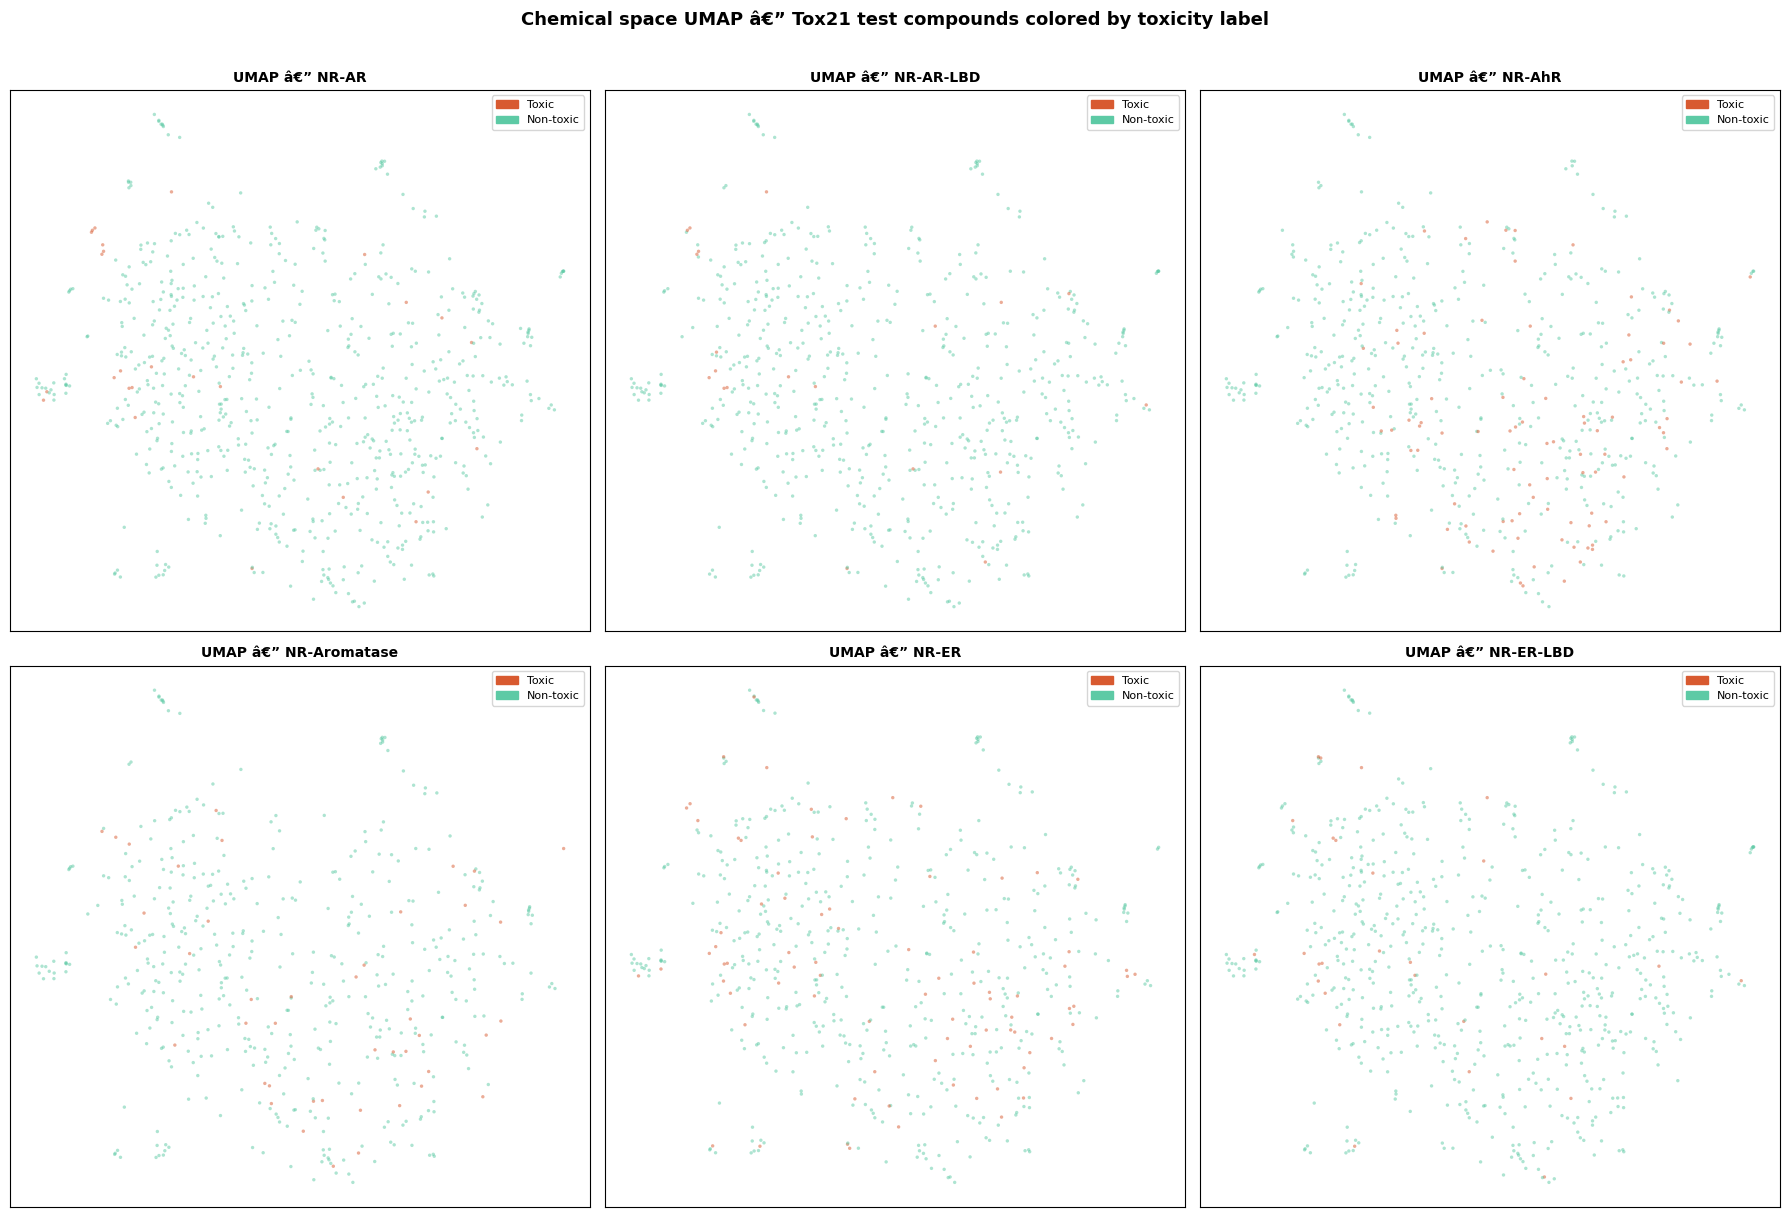

âœ“ UMAP visualization saved


In [17]:
# CELL 13 · Chemical Space Visualization — UMAP
# ─────────────────────────────────────────────────────────────────────────────

print("Computing UMAP embedding of chemical space...")
# Use test set Morgan fingerprints (2048 bits → 2D)
N_VIZ = min(3000, len(X_test))
idx_v = np.random.choice(len(X_test), N_VIZ, replace=False)

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_test_fp[idx_v])

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax_i, task in enumerate(TOX21_TASKS[:6]):
    task_idx = TOX21_TASKS.index(task)
    y_viz    = Y_test[idx_v, task_idx]
    mask_v   = ~np.isnan(y_viz)
    colors   = np.where(y_viz[mask_v] == 1, '#D85A30', '#5DCAA5')

    axes[ax_i].scatter(
        embedding[mask_v, 0], embedding[mask_v, 1],
        c=colors, alpha=0.5, s=6, linewidths=0
    )
    # Legend
    from matplotlib.patches import Patch
    axes[ax_i].legend(
        handles=[Patch(color='#D85A30', label='Toxic'),
                 Patch(color='#5DCAA5', label='Non-toxic')],
        fontsize=8, loc='best'
    )
    axes[ax_i].set_title(f'UMAP — {task}', fontweight='bold', fontsize=10)
    axes[ax_i].set_xticks([]); axes[ax_i].set_yticks([])

plt.suptitle('Chemical space UMAP — Tox21 test compounds colored by toxicity label',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./data/umap_chemical_space.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ UMAP visualization saved")


# ─────────────────────────────────────────────────────────────────────────────


In [22]:
# CELL 14 · GNN Atom-level Explanations (GNNExplainer)

try:
    from torch_geometric.explain import Explainer, GNNExplainer

    GNN_EXPLAINER_AVAILABLE = True
except ImportError:
    GNN_EXPLAINER_AVAILABLE = False
    print("GNNExplainer not available in this PyG version — using gradient saliency instead")

def gradient_saliency(model, data, task_idx, device):
    """Per-atom gradient saliency as fallback for atom attribution."""
    model.eval()
    data = data.to(device)
    x    = data.x.clone().requires_grad_(True)
    out  = model(x, data.edge_index, torch.zeros(x.shape[0], dtype=torch.long, device=device))
    loss = out[0, task_idx]
    loss.backward()
    atom_importance = x.grad.abs().sum(dim=1).detach().cpu().numpy()
    return atom_importance

def draw_molecule_with_weights(smi, weights, task_name, save_path):
    """Draw molecule with atoms colored by importance weight."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return

    # Normalize weights to [0,1]
    w_norm = (weights - weights.min()) / (np.ptp(weights) + 1e-9)

    drawer = rdMolDraw2D.MolDraw2DSVG(500, 400)
    drawer.drawOptions().addStereoAnnotation = False

    # Build highlight color map (gradient: green → red)
    atom_colors  = {}
    highlight_at = []
    for atom_i, w in enumerate(w_norm):
        if atom_i >= mol.GetNumAtoms():
            break
        r = float(w)
        g = float(1.0 - w)
        b = 0.2
        atom_colors[atom_i]  = (r, g, b)
        highlight_at.append(atom_i)

    drawer.DrawMolecule(mol,
                        highlightAtoms=highlight_at,
                        highlightAtomColors=atom_colors,
                        highlightBonds=[])
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText()

    with open(save_path, 'w') as f:
        f.write(svg)
    print(f"  ✓ Atom saliency map saved: {save_path}")
    return svg

# Pick a toxic compound from test set for visualization
best_task   = max(test_aucs_gnn, key=test_aucs_gnn.get)
task_idx_v  = TOX21_TASKS.index(best_task)
y_col_test  = Y_test[:, task_idx_v]
toxic_rows  = np.where(y_col_test == 1)[0]

if len(toxic_rows) > 0:
    row_i     = toxic_rows[0]
    smi_ex    = df_test.iloc[row_i]['canonical_smiles']
    data_ex   = test_graphs[row_i]
    weights   = gradient_saliency(model, data_ex, task_idx_v, DEVICE)
    os.makedirs('./data/explanations', exist_ok=True)
    svg_path  = f'./data/explanations/atom_saliency_{best_task}.svg'
    draw_molecule_with_weights(smi_ex, weights, best_task, svg_path)

    print(f"\n🔬 Atom saliency for compound: {smi_ex}")
    print(f"   Task: {best_task}")
    print(f"   Top 5 atoms by toxicity contribution:")
    top_atoms = np.argsort(weights)[::-1][:5]
    mol_ex    = Chem.MolFromSmiles(smi_ex)
    for rank, ai in enumerate(top_atoms, 1):
        if ai < mol_ex.GetNumAtoms():
            atom_sym = mol_ex.GetAtomWithIdx(int(ai)).GetSymbol()
            print(f"     {rank}. Atom {ai} ({atom_sym}): importance {weights[ai]:.4f}")
else:
    print("No toxic compounds found in test set for this task — try another task")

  ✓ Atom saliency map saved: ./data/explanations/atom_saliency_NR-ER-LBD.svg

🔬 Atom saliency for compound: CCCN(CCC)C(=O)C(CCC(=O)OCCCN1CCN(CCOC(=O)Cc2c(C)n(C(=O)c3ccc(Cl)cc3)c3ccc(OC)cc23)CC1)NC(=O)c1ccccc1
   Task: NR-ER-LBD
   Top 5 atoms by toxicity contribution:
     1. Atom 38 (Cl): importance 8.6646
     2. Atom 31 (N): importance 8.5048
     3. Atom 41 (C): importance 8.1664
     4. Atom 15 (C): importance 6.6129
     5. Atom 18 (N): importance 6.5566


In [23]:
# CELL 15 · Save Everything + Full Prediction Function
# ─────────────────────────────────────────────────────────────────────────────

def predict_toxicity(smiles_input: str, verbose=True):
    """
    Full prediction pipeline for a single SMILES string.
    Returns dict with probabilities for all 12 toxicity endpoints.
    """
    # Validate
    mol = Chem.MolFromSmiles(smiles_input)
    if mol is None:
        return {"error": "Invalid SMILES string"}
    smi = Chem.MolToSmiles(mol)

    results = {"smiles": smi, "predictions": {}, "top_features": {}}

    # ── GNN prediction
    data   = smiles_to_pyg(smi, [float('nan')] * len(TOX21_TASKS), TOX21_TASKS)
    model.eval()
    with torch.no_grad():
        data_dev = data.to(DEVICE)
        logits   = model(data_dev.x, data_dev.edge_index,
                         torch.zeros(data_dev.x.shape[0], dtype=torch.long, device=DEVICE))
        gnn_probs = torch.sigmoid(logits).cpu().numpy()[0]

    # ── XGBoost prediction
    fp   = mol_to_morgan_fp(smi)
    desc = mol_to_descriptors(smi)
    desc_scaled = scaler.transform(desc.reshape(1, -1))[0]
    X_pred = np.hstack([fp, desc_scaled]).reshape(1, -1)

    for t_i, task in enumerate(TOX21_TASKS):
        gnn_p = float(gnn_probs[t_i])
        if task in xgb_models:
            xgb_p = float(xgb_models[task].predict_proba(X_pred)[0, 1])
            ens_p = 0.6 * gnn_p + 0.4 * xgb_p
        else:
            ens_p = gnn_p
        results["predictions"][task] = round(ens_p, 4)

    # ── SHAP top features for best task
    top_task = max(results["predictions"], key=results["predictions"].get)
    if top_task in xgb_models:
        shap_exp     = shap.TreeExplainer(xgb_models[top_task])
        shap_vals    = shap_exp.shap_values(X_pred)
        sv           = shap_vals[1] if isinstance(shap_vals, list) else shap_vals
        top_feat_idx = np.argsort(np.abs(sv[0]))[::-1][:5]
        top_feats    = {}
        for fi in top_feat_idx:
            fname = FEATURE_NAMES[fi] if fi < len(FEATURE_NAMES) else f'feat_{fi}'
            top_feats[fname] = round(float(sv[0, fi]), 4)
        results["top_features"][top_task] = top_feats

    if verbose:
        print(f"\n{'â•'*55}")
        print(f"  Toxicity prediction for: {smi[:50]}...")
        print(f"{'â•'*55}")
        for task, prob in sorted(results["predictions"].items(),
                                  key=lambda x: x[1], reverse=True):
            risk  = "🔴 HIGH" if prob > 0.5 else ("🟡 MED" if prob > 0.3 else "🟢 LOW")
            bar   = "█" * int(prob * 20)
            print(f"  {task:<18} {prob:.3f}  {bar:<20}  {risk}")
        print(f"{'â•'*55}")
        print(f"\n  Top contributing features ({top_task}):")
        for feat, sv_val in results["top_features"].get(top_task, {}).items():
            direction = "↑ increases" if sv_val > 0 else "↓ decreases"
            print(f"    {feat:<30} SHAP: {sv_val:+.4f}  {direction} toxicity")

    return results

# ── Test on a known toxic compound (Aflatoxin B1 — known hepatotoxin)
print("Testing prediction on Aflatoxin B1 (known hepatotoxin)...")
result = predict_toxicity("O=c1oc2c(OC)cc3oc(=O)c4c(c3c2c1-c1ccccc1)CCC4")

# ── Test on aspirin (low toxicity expected)
print("\nTesting prediction on Aspirin...")
result_asp = predict_toxicity("CC(=O)Oc1ccccc1C(=O)O")

# Save final model artifacts
torch.save({
    'model_state_dict': model.state_dict(),
    'tox21_tasks':      TOX21_TASKS,
    'n_atom_features':  N_ATOM_FEATURES,
    'n_bond_features':  N_BOND_FEATURES,
    'best_val_auc':     best_val_auc,
}, "./models/gnn_final.pt")

joblib.dump(xgb_models,  "./models/xgb_models.pkl")
joblib.dump(scaler,      "./models/descriptor_scaler.pkl")
print("\n✓ All models saved to ./models/")
print("  Files: gnn_final.pt | xgb_models.pkl | descriptor_scaler.pkl")


# ─────────────────────────────────────────────────────────────────────────────


Testing prediction on Aflatoxin B1 (known hepatotoxin)...

Testing prediction on Aspirin...

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
  Toxicity prediction for: CC(=O)Oc1ccccc1C(=O)O...
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
  NR-ER              0.233  â–ˆâ–ˆâ–ˆâ–ˆ          ðŸŸ¢ LOW
  SR-HSE             0.210  â–ˆâ–ˆâ–ˆâ–ˆ          ðŸŸ¢ LOW
  SR-ARE             0.206  â–ˆâ–ˆâ–ˆâ–ˆ          ðŸŸ¢ LOW
  NR-AR              0.173  â–ˆâ–ˆâ–ˆ             ðŸŸ¢ LOW
  NR-ER-LBD          0.133  â–ˆâ–ˆ                ðŸŸ¢ LOW
  NR-AR-LBD          0.126  â–ˆâ–ˆ                ðŸŸ¢ LOW
  NR-AhR             0.099  â–ˆ                   ðŸŸ¢ LOW
  SR-ATAD5           0.063  â–ˆ                   ðŸŸ¢ LOW
  NR-PPAR-gamma      0.033                        ð

In [24]:
# Guardrail · Saved artifact checks

import os

required_artifacts = [
    "./models/gnn_final.pt",
    "./models/xgb_models.pkl",
    "./models/descriptor_scaler.pkl",
]

missing_artifacts = [p for p in required_artifacts if not os.path.exists(p)]
assert not missing_artifacts, "Missing saved artifacts: " + ", ".join(missing_artifacts)

print("Artifact guardrails passed.")

Artifact guardrails passed.


In [26]:
# Export: predictions + hyperparameters + losses

import os
import json
import pandas as pd
import numpy as np

os.makedirs("./models", exist_ok=True)

# Per-task metrics table
metrics_rows = []
for task in TOX21_TASKS:
    metrics_rows.append({
        "task": task,
        "xgboost_auc": float(test_aucs_xgb.get(task, np.nan)),
        "gnn_auc": float(test_aucs_gnn.get(task, np.nan)),
        "ensemble_auc": float(test_aucs_ensemble.get(task, np.nan)),
    })

metrics_df = pd.DataFrame(metrics_rows)
metrics_csv_path = "./models/test_task_metrics.csv"
metrics_df.to_csv(metrics_csv_path, index=False)

# Hyperparameters summary
hyperparams = {
    "xgboost": {
        "n_estimators": 500,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "eval_metric": "auc",
        "early_stopping_rounds": 30,
        "random_state": 42,
        "tree_method": "gpu_hist if cuda else hist",
    },
    "gnn": {
        "hidden": 256,
        "heads": 4,
        "dropout": 0.2,
        "n_layers": 3,
        "batch_size_train": 64,
        "batch_size_val": 128,
        "batch_size_test": 128,
        "optimizer": "AdamW",
        "lr": 1e-3,
        "weight_decay": 1e-5,
        "scheduler": "CosineAnnealingLR",
        "scheduler_T_max": 80,
        "scheduler_eta_min": 1e-5,
        "epochs": int(EPOCHS),
        "patience": int(PATIENCE),
        "gradient_clip_max_norm": 1.0,
    },
    "ensemble": {
        "gnn_weight": 0.6,
        "xgboost_weight": 0.4,
    },
}

# Loss history
loss_history = {
    "train_loss": [float(x) for x in train_losses],
    "val_mean_auc": [float(x) for x in val_aucs_history],
    "best_val_auc": float(best_val_auc),
}

summary = {
    "artifact_paths": {
        "gnn_best": "./models/gnn_best.pt",
        "gnn_final": "./models/gnn_final.pt",
        "xgb_models": "./models/xgb_models.pkl",
        "descriptor_scaler": "./models/descriptor_scaler.pkl",
    },
    "aggregate_metrics": {
        "xgboost_mean_auc": float(np.nanmean(list(test_aucs_xgb.values()))),
        "gnn_mean_auc": float(np.nanmean(list(test_aucs_gnn.values()))),
        "ensemble_mean_auc": float(np.nanmean(list(test_aucs_ensemble.values()))),
    },
    "hyperparameters": hyperparams,
    "loss_history": loss_history,
    "single_predictions": {
        "aflatoxin_b1": result if "result" in globals() else None,
        "aspirin": result_asp if "result_asp" in globals() else None,
    },
}

summary_json_path = "./models/experiment_summary.json"
with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

# Flat hyperparameter table for quick viewing
hp_rows = []
for section, vals in hyperparams.items():
    for key, value in vals.items():
        hp_rows.append({"section": section, "name": key, "value": value})

hp_df = pd.DataFrame(hp_rows)
hp_csv_path = "./models/hyperparameters.csv"
hp_df.to_csv(hp_csv_path, index=False)

print("Saved exports:")
print(f"- {summary_json_path}")
print(f"- {metrics_csv_path}")
print(f"- {hp_csv_path}")

Saved exports:
- ./models/experiment_summary.json
- ./models/test_task_metrics.csv
- ./models/hyperparameters.csv


In [27]:
# CELL 16 · Streamlit App (save as app.py — run separately)
# ─────────────────────────────────────────────────────────────────────────────
# Run in Colab with:
#   !pip install streamlit pyngrok -q
#   !streamlit run app.py &
#   from pyngrok import ngrok; print(ngrok.connect(8501))

STREAMLIT_APP_CODE = '''
import streamlit as st
import torch, joblib, numpy as np
from rdkit import Chem
from rdkit.Chem import Draw, AllChem, Descriptors
from rdkit.Chem.Draw import rdMolDraw2D
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import io, base64, warnings
warnings.filterwarnings("ignore")

# ── Page config
st.set_page_config(
    page_title="Drug Toxicity Predictor",
    page_icon="🧪",
    layout="wide",
)

st.markdown("""
<style>
  .toxic-high   { color: #D85A30; font-weight: bold; }
  .toxic-medium { color: #BA7517; font-weight: bold; }
  .toxic-low    { color: #1D9E75; font-weight: bold; }
  .block-metric { background: #f6f6f4; border-radius: 10px; padding: 12px 16px; }
</style>
""", unsafe_allow_html=True)

st.title("🧪 Drug Toxicity Predictor")
st.caption("CodeCure AI Hackathon · Track A — Multi-task GNN + XGBoost Ensemble")
st.markdown("---")

TOX21_TASKS = [
    "NR-AR","NR-AR-LBD","NR-AhR","NR-Aromatase",
    "NR-ER","NR-ER-LBD","NR-PPAR-gamma",
    "SR-ARE","SR-ATAD5","SR-HSE","SR-MMP","SR-p53"
]

EXAMPLES = {
    "Aflatoxin B1 (hepatotoxin)": "O=c1oc2c(OC)cc3oc(=O)c4c(c3c2c1-c1ccccc1)CCC4",
    "Aspirin (low risk)":          "CC(=O)Oc1ccccc1C(=O)O",
    "Bisphenol A (endocrine)":    "CC(C)(c1ccc(O)cc1)c1ccc(O)cc1",
    "Caffeine (low risk)":        "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
    "Tamoxifen (ER modulator)":   "CCC(=C(c1ccccc1)c1ccc(OCCN(C)C)cc1)c1ccccc1",
}

@st.cache_resource
def load_models():
    from drug_toxicity_colab import (
        AttentiveFP_Simple, smiles_to_pyg, mol_to_morgan_fp,
        mol_to_descriptors, DESCRIPTOR_LIST, N_ATOM_FEATURES,
        DEVICE, n_fp_bits
    )
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ckpt   = torch.load("./models/gnn_final.pt", map_location=device)
    model  = AttentiveFP_Simple(N_ATOM_FEATURES, 256, len(TOX21_TASKS), 4, 0.2, 3)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval().to(device)
    xgb_models = joblib.load("./models/xgb_models.pkl")
    scaler     = joblib.load("./models/descriptor_scaler.pkl")
    return model, xgb_models, scaler, device

def mol_to_svg(smi, weights=None):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    drawer = rdMolDraw2D.MolDraw2DSVG(450, 280)
    if weights is not None and len(weights) == mol.GetNumAtoms():
        w_norm = (weights - weights.min()) / (weights.ptp() + 1e-9)
        colors = {i: (float(w), float(1-w), 0.2) for i, w in enumerate(w_norm)}
        drawer.DrawMolecule(mol,
                            highlightAtoms=list(range(mol.GetNumAtoms())),
                            highlightAtomColors=colors, highlightBonds=[])
    else:
        drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    return drawer.GetDrawingText()

# ── Sidebar
with st.sidebar:
    st.header("Example compounds")
    for name, smi in EXAMPLES.items():
        if st.button(name, use_container_width=True):
            st.session_state["smiles_input"] = smi

    st.markdown("---")
    st.markdown("**Model info**")
    st.markdown("- GNN: 3-layer GAT, 256 hidden")
    st.markdown("- Baseline: XGBoost (500 trees)")
    st.markdown("- Ensemble: 60% GNN + 40% XGB")
    st.markdown("- Features: ECFP4 + RDKit descriptors")
    st.markdown("- Eval: ROC-AUC on scaffold split")

# ── Main input
smiles_input = st.text_input(
    "Enter SMILES string",
    value=st.session_state.get("smiles_input", "CC(=O)Oc1ccccc1C(=O)O"),
    placeholder="e.g. CC(=O)Oc1ccccc1C(=O)O",
    key="smiles_box"
)

col_run, _ = st.columns([1, 3])
run_clicked = col_run.button("ðŸ” Predict Toxicity", type="primary", use_container_width=True)

if run_clicked or smiles_input:
    mol = Chem.MolFromSmiles(smiles_input)
    if mol is None:
        st.error("Invalid SMILES string. Please check and try again.")
        st.stop()

    smi = Chem.MolToSmiles(mol)

    try:
        model, xgb_models, scaler, device = load_models()
        from drug_toxicity_colab import (
            smiles_to_pyg, mol_to_morgan_fp, mol_to_descriptors,
            DESCRIPTOR_LIST, n_fp_bits
        )
        FEATURE_NAMES = ([f"ECFP4_bit_{i}" for i in range(n_fp_bits)] + DESCRIPTOR_LIST)

        # Predictions
        data  = smiles_to_pyg(smi, [float("nan")] * len(TOX21_TASKS), TOX21_TASKS)
        with torch.no_grad():
            d = data.to(device)
            logits = model(d.x, d.edge_index,
                           torch.zeros(d.x.shape[0], dtype=torch.long, device=device))
            gnn_probs = torch.sigmoid(logits).cpu().numpy()[0]

        fp          = mol_to_morgan_fp(smi)
        desc        = mol_to_descriptors(smi)
        desc_scaled = scaler.transform(desc.reshape(1, -1))[0]
        X_pred      = np.hstack([fp, desc_scaled]).reshape(1, -1)

        predictions = {}
        for t_i, task in enumerate(TOX21_TASKS):
            gp = float(gnn_probs[t_i])
            if task in xgb_models:
                xp = float(xgb_models[task].predict_proba(X_pred)[0, 1])
                predictions[task] = 0.6*gp + 0.4*xp
            else:
                predictions[task] = gp

        # Gradient saliency
        model.eval()
        d2 = data.to(device)
        x_inp = d2.x.clone().requires_grad_(True)
        top_task = max(predictions, key=predictions.get)
        top_ti   = TOX21_TASKS.index(top_task)
        out = model(x_inp, d2.edge_index, torch.zeros(x_inp.shape[0], dtype=torch.long, device=device))
        out[0, top_ti].backward()
        weights = x_inp.grad.abs().sum(dim=1).detach().cpu().numpy()

    except Exception as e:
        st.error(f"Prediction failed: {e}")
        st.info("Make sure model files are in ./models/ and you\'ve run all Colab cells.")
        st.stop()

    # ── Layout
    col_mol, col_res = st.columns([1, 1.6])

    with col_mol:
        st.subheader("Molecular structure")
        svg = mol_to_svg(smi, weights)
        if svg:
            b64 = base64.b64encode(svg.encode()).decode()
            st.markdown(
                f\'<img src="data:image/svg+xml;base64,{b64}" width="100%">\',
                unsafe_allow_html=True
            )
        st.caption("Atoms colored by toxicity contribution (green=low, red=high)")

        mw   = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        hbd  = Descriptors.NumHDonors(mol)
        hba  = Descriptors.NumHAcceptors(mol)

        st.markdown("**Physicochemical properties**")
        c1,c2,c3 = st.columns(3)
        c1.metric("MW",      f"{mw:.1f}")
        c2.metric("logP",    f"{logp:.2f}")
        c3.metric("TPSA",    f"{tpsa:.1f}")
        c1.metric("H-donors",f"{hbd}")
        c2.metric("H-acc",   f"{hba}")

    with col_res:
        st.subheader("Toxicity predictions")
        overall = max(predictions.values())
        if overall > 0.5:
            st.error(f"âš ï¸ High toxicity risk detected (max probability: {overall:.1%})")
        elif overall > 0.3:
            st.warning(f"⚡ Moderate toxicity signals present (max: {overall:.1%})")
        else:
            st.success(f"✅ Low toxicity risk overall (max: {overall:.1%})")

        # Bar chart
        fig, ax = plt.subplots(figsize=(8, 5))
        tasks_s = sorted(predictions.keys(), key=lambda t: predictions[t], reverse=True)
        vals_s  = [predictions[t] for t in tasks_s]
        bar_colors = ["#D85A30" if v > 0.5 else "#BA7517" if v > 0.3 else "#5DCAA5"
                      for v in vals_s]
        bars = ax.barh(tasks_s[::-1], vals_s[::-1], color=bar_colors[::-1],
                       edgecolor="gray", linewidth=0.4, height=0.65)
        ax.axvline(0.5, color="#D85A30", linestyle="--", alpha=0.7, label="Risk threshold")
        ax.axvline(0.3, color="#BA7517", linestyle="--", alpha=0.5)
        ax.set_xlim(0, 1.0)
        ax.set_xlabel("Toxicity probability (ensemble)")
        legend_patches = [
            mpatches.Patch(color="#D85A30", label="High (>0.5)"),
            mpatches.Patch(color="#BA7517", label="Medium (0.3–0.5)"),
            mpatches.Patch(color="#5DCAA5", label="Low (<0.3)"),
        ]
        ax.legend(handles=legend_patches, fontsize=9, loc="lower right")
        for bar, val in zip(bars, vals_s[::-1]):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f"{val:.2f}", va="center", fontsize=9)
        plt.tight_layout()
        st.pyplot(fig, use_container_width=True)

st.markdown("---")
st.caption("Built for CodeCure AI Hackathon · Models: Multi-task GNN + XGBoost Ensemble · Data: Tox21 (NIH)")
'''

with open('./app.py', 'w') as f:
    f.write(STREAMLIT_APP_CODE)

print("✓ Streamlit app saved to ./app.py")
print("\nTo run the app in Colab:")
print("  !pip install streamlit pyngrok -q")
print("  !streamlit run app.py &")
print("  from pyngrok import ngrok")
print("  print(ngrok.connect(8501))")


âœ“ Streamlit app saved to ./app.py

To run the app in Colab:
  !pip install streamlit pyngrok -q
  !streamlit run app.py &
  from pyngrok import ngrok
  print(ngrok.connect(8501))
